# Supervised Classification: Lithology Classification with Well Logs

**Well log interpretation is a critical yet time-intensive task in subsurface exploration, requiring geoscientists to analyze complex datasets to infer lithology accurately. Developing an automated solution that can instantly and accurately classify lithology has significant implications for the efficiency and effectiveness of geological workflows. This project aims to address this challenge by leveraging machine learning to interpret lithology from various well logs provided from the FORCE 2020 ML competition. By utilizing logs with pre-labeled lithology data, the goal is to examine whether a robust and effective machine learning model can be developed to classify lithology reliably, streamlining interpretation and supporting more informed decision-making in geoscience applications.**

## Well Log Dataset Reference  

This dataset is sourced from the **FORCE 2020 Machine Learning Lithology Prediction Challenge**. It is publicly available and was released on **November 18, 2020**. The dataset includes well log data for multiple wells, providing lithology labels and various petrophysical measurements.  

**Citation:**  
Bormann, P., Aursand, P., & Dilib, F. (2020). *FORCE Machine Learning Competition*. Available at: [GitHub Repository](https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition).  

If you use this data, software, or report, please cite it using these metadata.  


## Project Setup

### Import Libraries

In [48]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import requests
!pip install lasio
import lasio

### Import and Clean Data

In [49]:
# GitHub repository details
owner = 'bolgebrygg'
repo = 'Force-2020-Machine-Learning-competition'
directory = 'lithology_competition/data/las_files_Lithostrat_data'

# GitHub API URL to fetch contents of the directory
api_url = f'https://api.github.com/repos/{owner}/{repo}/contents/{directory}'

# Fetch the directory contents
response = requests.get(api_url)

# List of files that caused errors (will be skipped)
skip_files = {
    "15_9-23.las", "16_1-2.las", "16_1-6 A.las", "16_10-5.las", "16_11-1 ST3.las",
    "16_2-11 A.las", "16_2-16.las", "16_2-6.las", "16_2-7.las", "16_5-3.las",
    "16_7-4.las", "16_8-1.las", "17_11-1.las", "17_4-1.las", "25_10-10.las",
    "25_10-9.las", "25_11-15.las", "25_11-19 S.las", "25_11-24.las", "25_11-5.las",
    "25_2-13 T4.las", "25_4-5.las", "25_6-1.las", "25_6-2.las", "25_6-3.las",
    "25_8-5 S.las", "30_3-5 S.las", "31_2-1.las", "31_2-19 S.las", "31_2-21 S.las",
    "31_3-1.las", "31_3-3.las", "31_3-4.las", "31_4-10.las", "31_5-4 S.las",
    "31_6-5.las", "31_6-8.las", "32_2-1.las", "33_5-2.las", "33_6-3 S.las",
    "33_9-1.las", "34_10-16 R.las", "34_10-19.las", "34_10-33.las", "34_11-1.las",
    "34_11-2 S.las", "34_12-1.las", "34_3-1 A.las", "34_3-2 S.las", "34_3-3 A.las",
    "34_4-10 R.las", "34_5-1 A.las", "34_5-1 S.las", "34_6-1 S.las", "34_7-13.las",
    "34_7-20.las", "34_8-3.las", "34_8-7 R.las", "35_11-10.las", "35_11-12.las",
    "35_11-13.las", "35_11-15 S.las", "35_3-7 S.las", "35_4-1.las", "35_6-2 S.las",
    "35_8-4.las", "35_8-6 S.las", "35_9-10 S.las", "35_9-2.las", "35_9-5.las",
    "35_9-6 S.las", "35_9-7.las", "35_9-8.las", "36_7-3.las", "7_1-1.las",
    "7_1-2 S.las"
}

# Required columns for analysis
columns_to_keep = ['FORCE_2020_LITHOFACIES_LITHOLOGY', 'SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DEPTH_MD']

# Initialize an empty list to store DataFrames
dataframes = []

if response.status_code == 200:
    contents = response.json()

    # Get a list of valid LAS files
    las_files = [
        f"https://raw.githubusercontent.com/{owner}/{repo}/master/{directory}/{file['name']}"
        for file in contents if file['name'].endswith('.las') and file['name'] not in skip_files
    ]

    # Read LAS files
    for i, las_url in enumerate(las_files):
        try:
            las = lasio.read(las_url)
            df = las.df()

            # Ensure all required logs are present
            if not df.empty and all(col in df.columns for col in columns_to_keep):
                df = df[columns_to_keep]  # Keep only relevant columns
                df['Source'] = os.path.basename(las_url)  # Track file origin
                df['Well_ID'] = i  # Add a Well ID
                dataframes.append(df)
            else:
                print(f"Skipping file (missing required logs): {las_url}")

        except Exception as e:
            print(f"Error reading file {las_url}: {e}")

    # Combine all DataFrames into one
    if dataframes:
        combined_df = pd.concat(dataframes, ignore_index=True)

        # Drop rows where NaN values are present
        cleaned_df = combined_df.dropna()

        # Remove rows where any of the specified columns have negative values
        columns_to_check = ['PEF', 'GR', 'RHOB', 'DTC', 'NPHI']
        cleaned_df = cleaned_df[(cleaned_df[columns_to_check] >= 0).all(axis=1)]

        # Print final shape and preview data
        print("Final DataFrame shape:", cleaned_df.shape)
        print(cleaned_df.head())

    else:
        print("No valid dataframes to combine.")
else:
    print(f"Failed to fetch directory contents: {response.status_code}")

Final DataFrame shape: (284013, 10)
      FORCE_2020_LITHOFACIES_LITHOLOGY         SP         DTC      NPHI  \
7327                           30000.0  45.547737  147.837677  0.765867   
7328                           65000.0  45.914387  142.382431  0.800262   
7329                           65000.0  46.039104  138.258331  0.765957   
7330                           65000.0  46.826984  139.198914  0.702521   
7331                           65000.0  46.950382  144.290085  0.639708   

           PEF         GR      RHOB     DEPTH_MD       Source  Well_ID  
7327  1.631495  55.892757  1.774626  1138.703980  15_9-13.las        0  
7328  1.645080  60.929138  1.800986  1138.855957  15_9-13.las        0  
7329  1.645873  62.117264  1.817696  1139.008057  15_9-13.las        0  
7330  1.620216  61.010860  1.829333  1139.160034  15_9-13.las        0  
7331  1.504854  58.501236  1.813854  1139.312012  15_9-13.las        0  


### Fix Lithology labels

In [50]:
# Define the lithology keys
lithology_keys = {
    30000: 'Sandstone',
    65030: 'Sandstone/Shale',
    65000: 'Shale',
    80000: 'Marl',
    74000: 'Dolomite',
    70000: 'Limestone',
    70032: 'Chalk',
    88000: 'Halite',
    86000: 'Anhydrite',
    99000: 'Tuff',
    90000: 'Coal',
    93000: 'Basement'
}

# Ensure the DataFrame is a copy to avoid SettingWithCopyWarning
cleaned_df = cleaned_df.copy()

# Create a new column 'Lithology' by mapping the lithology codes to descriptions
cleaned_df.loc[:, 'Lithology'] = cleaned_df['FORCE_2020_LITHOFACIES_LITHOLOGY'].map(lithology_keys).astype(str)

# Remove rows where Lithology is Chalk, Dolomite, or Halite
cleaned_df = cleaned_df[~cleaned_df['Lithology'].isin(['Chalk', 'Dolomite', 'Halite'])]

# Reset the index of the DataFrame, starting from 0
cleaned_df = cleaned_df.reset_index(drop=True)

# Print the final cleaned DataFrame
print("Final DataFrame shape:", cleaned_df.shape)

# Print the first few rows to confirm
print("----------------------------------------------")
print('First Few Rows:')
print(cleaned_df.head())

Final DataFrame shape: (279599, 11)
----------------------------------------------
First Few Rows:
   FORCE_2020_LITHOFACIES_LITHOLOGY         SP         DTC      NPHI  \
0                           30000.0  45.547737  147.837677  0.765867   
1                           65000.0  45.914387  142.382431  0.800262   
2                           65000.0  46.039104  138.258331  0.765957   
3                           65000.0  46.826984  139.198914  0.702521   
4                           65000.0  46.950382  144.290085  0.639708   

        PEF         GR      RHOB     DEPTH_MD       Source  Well_ID  Lithology  
0  1.631495  55.892757  1.774626  1138.703980  15_9-13.las        0  Sandstone  
1  1.645080  60.929138  1.800986  1138.855957  15_9-13.las        0      Shale  
2  1.645873  62.117264  1.817696  1139.008057  15_9-13.las        0      Shale  
3  1.620216  61.010860  1.829333  1139.160034  15_9-13.las        0      Shale  
4  1.504854  58.501236  1.813854  1139.312012  15_9-13.las     

**My data importation is relatively straight forward. For each well, I am assigning a number to reference back to the well. As I import each .las file, I obtain any columns pertinent to my analysis, then append all of those values to one large dataframe. At first, not all of the wells contained the necessary logs, and other gave errors. To speed up the data import, I put these into a list which I skip on import. Once that dataframe containing all of the well data is created, I remove rows with Nan values. This ensures I can analyze all of the pertinent wells at any given row. I also remove rows where there is an unrealistic value, such as negative density values. The lithology labels are numbers, but I want the labels to be more intuitive, so I am implementing a dictionary to convert those to text. This will make interpretations much easier later on. I also remove Chalk, Dolomite, and Halite lithologies as there are not enough samples to effectively train and test the model. From here, I reset the indices for ease of use later on. This data cleaning process has left me with 279,599 rows and 11 columns, which should be more than enough for data analysis. However, by today's standards I wouldn't call this "big data" as it is purely numerical and doesn't take up very much memory.**

## EDA

### Data Statistics

In [51]:
# Calculate pertinent stats of cleaned data
cleaned_df.describe()

,FORCE_2020_LITHOFACIES_LITHOLOGY,SP,DTC,NPHI,PEF,GR,RHOB,DEPTH_MD,Well_ID
count,279599.000000,279599.000000,279599.000000,279599.000000,279599.000000,279599.000000,279599.000000,279599.000000,279599.000000
mean,60219.837589,61.171710,107.049810,0.343638,6.133779,71.741922,2.308656,2420.732332,20.544866
std,14151.484005,59.467018,28.834940,0.120880,11.926246,29.380532,0.240607,829.949529,13.884918
min,30000.000000,-178.194748,7.415132,0.000001,0.099718,0.898921,1.127937,445.065094,0.000000
25%,65000.000000,36.540873,83.686630,0.255643,3.286904,54.041800,2.124153,1845.257507,8.000000
50%,65000.000000,60.788467,99.438591,0.345240,3.997761,71.022820,2.352713,2443.402100,24.000000
75%,65000.000000,82.245674,134.533081,0.441197,5.223362,87.163013,2.502452,2996.817627,33.000000
max,99000.000000,273.084320,320.478882,0.901139,376.600586,1076.963867,3.353153,4819.024902,41.000000


**The dataset contains 279,599 rows of well log data with various features, including SP, DTC, NPHI, PEF, GR, RHOB, and depth. The lithology codes (FORCE_2020_LITHOFACIES_LITHOLOGY) range from 30,000 to 99,000, with a mean of 60,219, indicating the prevalence of certain lithologies like shale (65,000). Key features show significant variability, with SP ranging from -178.19 to 273.08 and GR from 0.10 to 376.60, reflecting diverse lithological conditions. The mean DTC (107.05) and RHOB (2.31) fall within expected subsurface ranges, while NPHI has a mean of 0.34. Depth spans from 445 to 4819 meters, covering a wide range of geological intervals. The dataset consists of data from 41 wells, with Well_IDs ranging from 0 to 41. Overall, the dataset provides a large and diverse collection of measurements, making it well-suited for lithology classification.**

### Seaborn Pair Plot

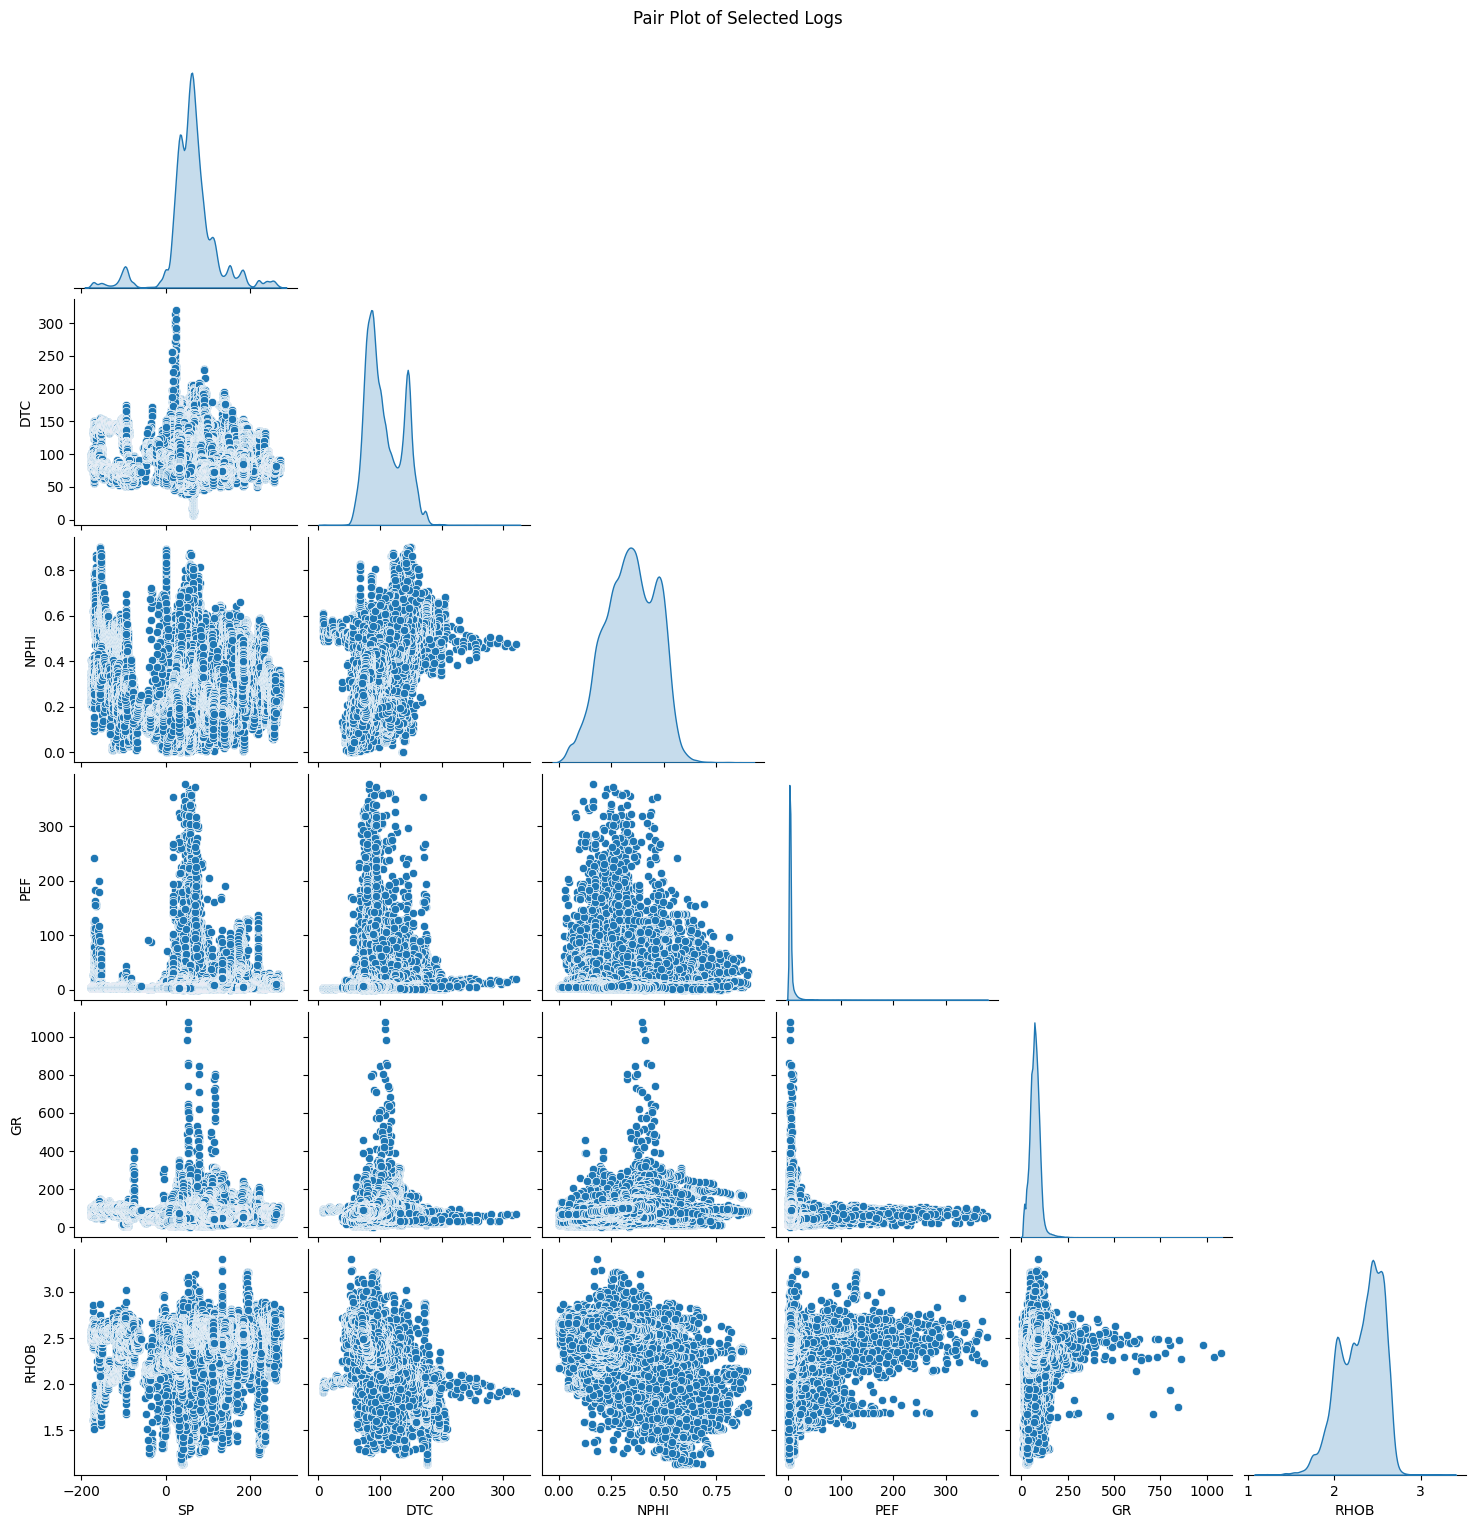

In [52]:
# Select the columns of interest
columns_to_plot = ['SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB']
df_to_plot = cleaned_df[columns_to_plot].dropna()  # Drop NaN values for these columns

# Create a pair plot
sns.pairplot(df_to_plot, diag_kind='kde', corner=True)

# Display the plot
plt.suptitle('Pair Plot of Selected Logs', y=1.02)
plt.show()

**A lot of the trends we see in the seaborn plots are consistent with what we would expect from well logs. For example, as NPHI increases, RHOB tends to decrease. Another place we see familiar trends is with RHOB, NPHI, and DTC. As DTC increases, RHOB tends to decrease and NPHI tends to increase, which we would expect. I also see that SP seems to form two clusters when combined with RHOB, NPHI, and DTC.  In GR and PEF logs, we see some large outliers which I will examine later on in this EDA. I also saw some interesting distributions which I will look at more closely later on.**

### Correlation Matrix Heatmap

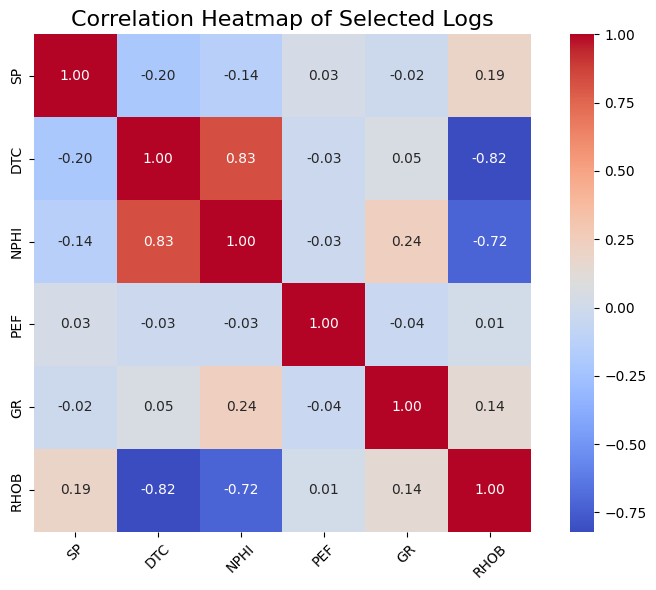

In [53]:
# Compute the correlation matrix
correlation_matrix = df_to_plot.corr()

# Set up the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)

# Add labels and title
plt.title('Correlation Heatmap of Selected Logs', fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Display the plot
plt.show()

**As previously seen in the seaborn plots, the strongest trends are present between RHOB, DTC, and PHI. DTC and NPHI exhibit a positive trend, as both increase in formations with higher porosity, where sound waves travel slower due to fluid-filled pore spaces. On the other hand, DTC and RHOB show a negative trend, as denser rocks allow faster sound wave travel (lower DTC) while also exhibiting higher bulk density (higher RHOB). These trends are consistent with the physical properties of rock formations and their response to acoustic and density logging tools. Besides the aforementioned trends, none of the other trends are as strong, which is consistent with the seaborn plots.**

### Data Distributions

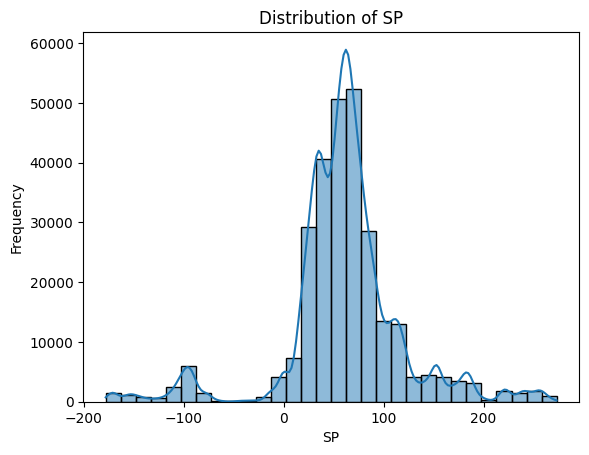

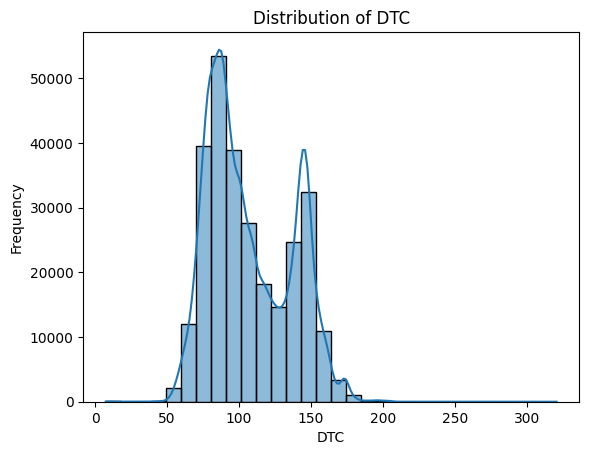

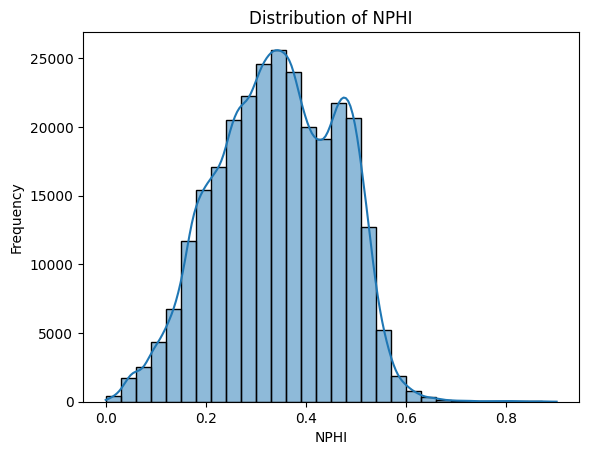

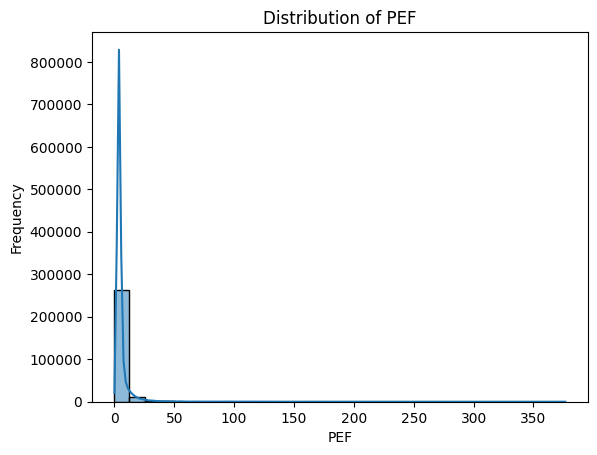

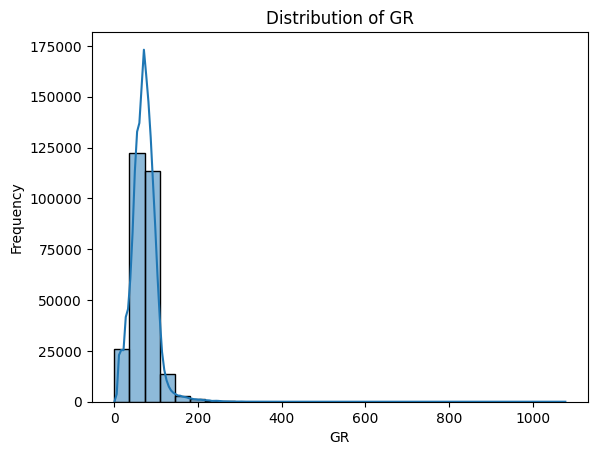

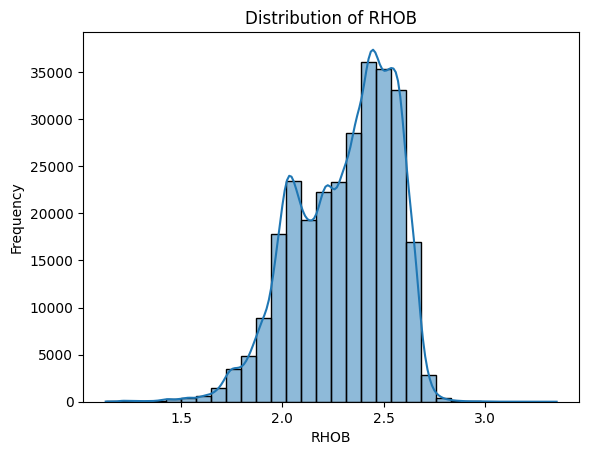

In [54]:
# Plot data distributions
for col in ['SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB']:
    sns.histplot(cleaned_df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**Reexamining the distributions of each log showed some really interesting trends. SP, DTC, NPHI, and RHOB have more bimodal distributions, while PEF and GR have more unimodal distributions. This makes sense for PEF and GR, as the vast majority of values are closer to 0, with the exception of some outliers. I am not completely sure why we see bimodal distributions with the others, but I think that they could represent the two dominanat lithologies present across these logs.**

### Outlier Analysis


Outliers in SP: 32449
Outlier value range for SP: [-178.1947479, 273.08432007]

Outliers in DTC: 47
Outlier value range for DTC: [7.4151320457, 320.47888184]

Outliers in NPHI: 208
Outlier value range for NPHI: [0.7199277878, 0.9011391997]

Outliers in PEF: 31900
Outlier value range for PEF: [0.0997178704, 376.60058594]

Outliers in GR: 5575
Outlier value range for GR: [0.8989213109, 1076.9638672]

Outliers in RHOB: 940
Outlier value range for RHOB: [1.1279368401, 3.3531529903]


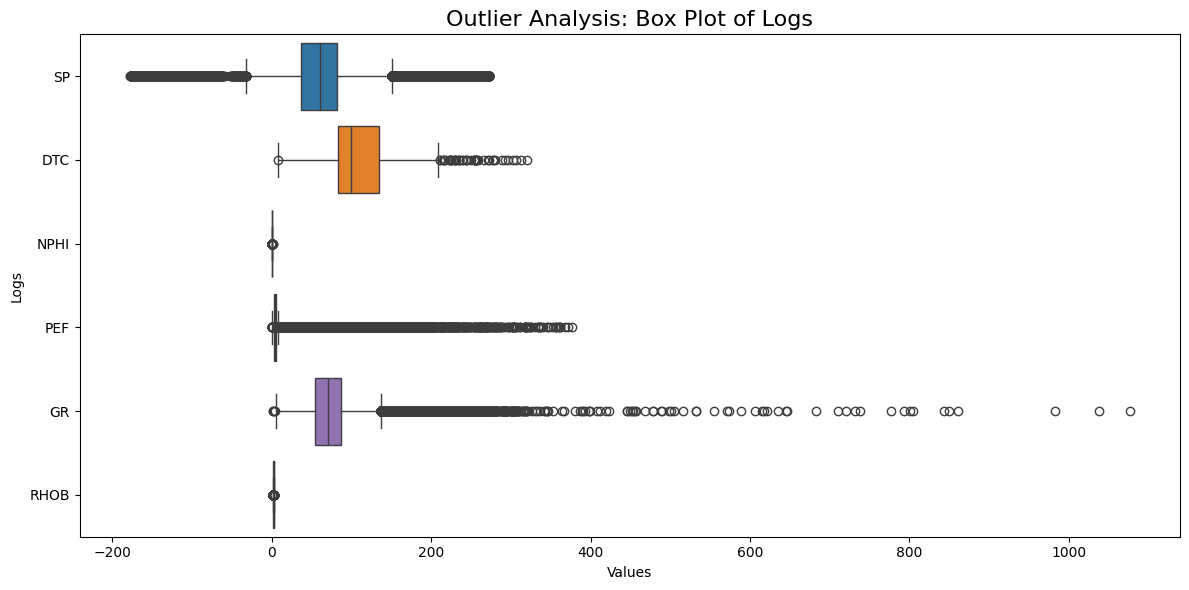

In [55]:
# Outlier analysis with outlier ranges
for col in ['SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB']:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = cleaned_df[(cleaned_df[col] < lower_bound) | (cleaned_df[col] > upper_bound)]

    # Print the results
    print(f'\nOutliers in {col}: {len(outliers)}')
    if not outliers.empty:
        print(f'Outlier value range for {col}: [{outliers[col].min()}, {outliers[col].max()}]')
    else:
        print(f'No outliers detected in {col}.')

# Columns to analyze
columns_to_analyze = ['SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB']

# Set up the plot
plt.figure(figsize=(12, 6))

# Create a boxplot for each column
sns.boxplot(data=cleaned_df[columns_to_analyze], orient="h", showfliers=True)

# Add titles and labels
plt.title('Outlier Analysis: Box Plot of Logs', fontsize=16)
plt.xlabel('Values')
plt.ylabel('Logs')
plt.tight_layout()

# Display the plot
plt.show()

**The outlier analysis provides further insight into the trends observed in the seaborn plots and aligns with what we would expect from these logs. NPHI and RHOB had relatively few outliers, which makes sense—NPHI is typically bounded between 0 and 1, and while RHOB doesn’t have a strict range, most values generally fall between 1-4 g/cc, making extreme deviations unlikely. DTC also had very few outliers (47), suggesting it follows a more normal distribution.**

**In contrast, SP and PEF had the highest number of outliers, with 32,449 and 31,900 values falling outside the typical range, respectively. PEF values are mostly low, but the presence of extreme high values aligns with known variations in lithology. GR also showed a significant number of outliers (5,575), with most values clustering around 50 but a substantial number reaching much higher values, indicating variations in shale content. SP had a wide range of outliers but remained closer to expected values compared to GR and PEF. Overall, while some features show expected distributions, others, like SP, GR, and PEF, have substantial deviations that could impact model performance and may require further preprocessing.**

##ML Analysis

### Import Libraries

In [56]:
# Import libraries
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

### Split Data

In [57]:
# Split the data into training and testing sets based on Well_ID
train_wells = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]  # Well IDs for training
test_wells = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]         # Well IDs for testing

# Training data: rows where Well_ID is in train_wells
train_df = cleaned_df[cleaned_df['Well_ID'].isin(train_wells)]

# Testing data: rows where Well_ID is in test_wells
test_df = cleaned_df[cleaned_df['Well_ID'].isin(test_wells)]

# Separate features and target for training and testing
features = ['SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB']
target = 'Lithology'  # Ensure this column is properly labeled and encoded

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Print shapes to verify
print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")
print(f'Training: {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100}% of total data points')
print(f'Testing: {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100}% of total data points')

print('--------------------------------------')

print("Training Class Distribution:\n", y_train.value_counts())
print("Testing Class Distribution:\n", y_test.value_counts())

Training data shape: (190629, 6), (190629,)
Testing data shape: (88970, 6), (88970,)
Training: 68.17942839566665% of total data points
Testing: 31.82057160433335% of total data points
--------------------------------------
Training Class Distribution:
 Lithology
Shale              117774
Sandstone           30002
Sandstone/Shale     21073
Limestone           13651
Marl                 4709
Tuff                 2079
Coal                 1341
Name: count, dtype: int64
Testing Class Distribution:
 Lithology
Shale              52343
Sandstone          16514
Sandstone/Shale    16106
Limestone           1823
Marl                1658
Coal                 506
Tuff                  20
Name: count, dtype: int64


In [58]:
# Split the data into training and testing sets based on Well_ID
train_wells = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]  # Training wells
test_wells = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]  # Testing wells

# Training data: rows where Well_ID is in train_wells
train_df = cleaned_df[cleaned_df['Well_ID'].isin(train_wells)]

# Testing data: rows where Well_ID is in test_wells
test_df = cleaned_df[cleaned_df['Well_ID'].isin(test_wells)]

# Separate features and target for training and testing
features = ['SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB']
target = 'Lithology'  # Ensure this column is properly labeled and encoded

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Apply StandardScaler to the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data, then transform
X_test_scaled = scaler.transform(X_test)  # Transform test data using same scaler

# Print shapes to verify
print(f"Training data shape: {X_train_scaled.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test_scaled.shape}, {y_test.shape}")
print(f'Training: {X_train_scaled.shape[0]/(X_train_scaled.shape[0]+X_test_scaled.shape[0])*100:.2f}% of total data points')
print(f'Testing: {X_test_scaled.shape[0]/(X_train_scaled.shape[0]+X_test_scaled.shape[0])*100:.2f}% of total data points')

print('--------------------------------------')

print("Training Class Distribution:\n", y_train.value_counts())
print("Testing Class Distribution:\n", y_test.value_counts())

Training data shape: (190629, 6), (190629,)
Testing data shape: (88970, 6), (88970,)
Training: 68.18% of total data points
Testing: 31.82% of total data points
--------------------------------------
Training Class Distribution:
 Lithology
Shale              117774
Sandstone           30002
Sandstone/Shale     21073
Limestone           13651
Marl                 4709
Tuff                 2079
Coal                 1341
Name: count, dtype: int64
Testing Class Distribution:
 Lithology
Shale              52343
Sandstone          16514
Sandstone/Shale    16106
Limestone           1823
Marl                1658
Coal                 506
Tuff                  20
Name: count, dtype: int64


**I chose to split up my data on a well basis. This represents a far more realistic scenario for this project. Presumably, an interpreter could mark lithologies in a few wells, and train the model on that. Then, they could use that model elsewhere in the basin/similar geographic region to get lithology. This method of training on two wells, and testing on one yields a 68/32% training and testing split, which is consistent with what is recommended for the following supervised methods. I also chose to show the quantity of each lithology in the training/testing data. This is important context, for my following supervised ML interpretations, as less common lithologies like marl and tuff may not perform as strong as shale which has the most data to train and test with.**

### Gradient Boosting Classifier

Classification Report:
                 precision    recall  f1-score   support

           Coal       0.41      0.19      0.26       506
      Limestone       0.05      0.05      0.05      1823
           Marl       0.03      0.01      0.01      1658
      Sandstone       0.59      0.52      0.55     16514
Sandstone/Shale       0.32      0.17      0.22     16106
          Shale       0.73      0.88      0.80     52343
           Tuff       0.00      0.00      0.00        20

       accuracy                           0.65     88970
      macro avg       0.30      0.26      0.27     88970
   weighted avg       0.60      0.65      0.61     88970



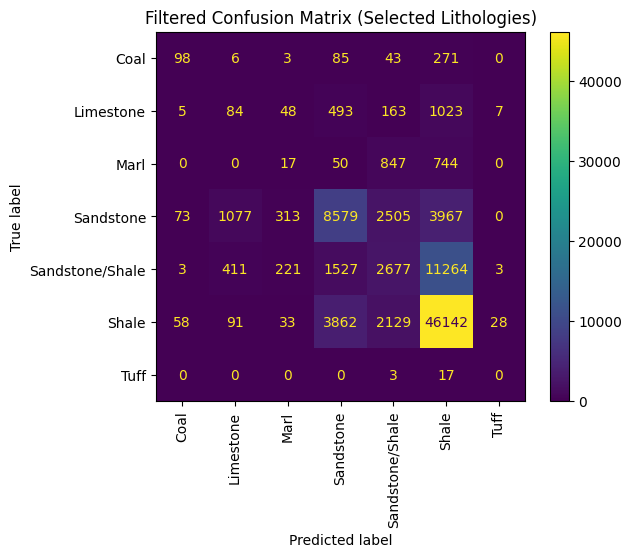

In [59]:
# Create a sequential mapping (0,1,2...) for lithology classes
unique_lithologies = sorted(lithology_keys.keys())  # Ensure consistent ordering
lithology_encoding = {code: idx for idx, code in enumerate(unique_lithologies)}  # Lithology -> Index
lithology_decoding = {idx: lithology_keys[code] for code, idx in lithology_encoding.items()}  # Reverse Mapping

# **Convert training & testing labels to sequential index values**
y_train_numeric = train_df['FORCE_2020_LITHOFACIES_LITHOLOGY'].map(lithology_encoding)
y_test_numeric = test_df['FORCE_2020_LITHOFACIES_LITHOLOGY'].map(lithology_encoding)

# Ensure there are no NaNs in the labels (fixes previous error)
y_train_numeric = y_train_numeric.dropna().astype(int)
y_test_numeric = y_test_numeric.dropna().astype(int)

# Convert data to DMatrix format for XGBoost
dtrain = xgb.DMatrix(X_train.loc[y_train_numeric.index], label=y_train_numeric)
dtest = xgb.DMatrix(X_test.loc[y_test_numeric.index], label=y_test_numeric)

# Define Parameters for Model
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': len(lithology_encoding),  # Number of unique lithology classes
    'tree_method': 'hist',  # Optimized for GPU training
    'device': 'cuda',  # Enables GPU acceleration
    'eval_metric': 'mlogloss',  # Log loss for multi-class classification
    'random_state': 42
}

# Train the model
gbc = xgb.train(params, dtrain, num_boost_round=100)

# Make predictions (numeric lithology indices)
y_pred_numeric = gbc.predict(dtest)

# Convert numeric predictions back to lithology names
y_pred_labels = [lithology_decoding[int(pred)] for pred in y_pred_numeric]
y_test_labels = [lithology_decoding[int(label)] for label in y_test_numeric]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))

# Define lithologies to keep
selected_lithologies = ['Coal', 'Limestone', 'Marl', 'Sandstone', 'Sandstone/Shale', 'Shale', 'Tuff']

# Filter y_test_labels and y_pred_labels to only include selected lithologies
filtered_indices = [i for i, label in enumerate(y_test_labels) if label in selected_lithologies]

y_test_filtered = [y_test_labels[i] for i in filtered_indices]
y_pred_filtered = [y_pred_labels[i] for i in filtered_indices]

# Compute the filtered confusion matrix
conf_matrix = confusion_matrix(y_test_filtered, y_pred_filtered, labels=selected_lithologies)

# Plot the filtered confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=selected_lithologies)
disp.plot(cmap="viridis", xticks_rotation='vertical')
plt.title("Filtered Confusion Matrix (Selected Lithologies)")
plt.show()

**The gradient boosting classifier performed best with Shale, achieving an f1-score of 0.80 due to its strong recall (0.88) and precision (0.73). Sandstone followed with an f1-score of 0.55, though its recall (0.52) suggests some misclassification. Sandstone/Shale struggled with an f1-score of 0.22, largely due to its low recall (0.17), while Coal, Limestone, and Marl performed even worse, all with f1-scores below 0.26. Tuff had no successful predictions, likely due to its minimal support (20 samples). The overall accuracy was 0.65, heavily influenced by the dominant Shale class. The macro average f1-score was 0.27, indicating poor performance across underrepresented lithologies, while the weighted average f1-score was higher at 0.61, benefiting from the classifier’s stronger performance on Shale and Sandstone. The significant class imbalance, with Shale (52,343 samples) vastly outnumbering others like Coal (506) and Limestone (1,823), likely contributed to the poor classification of minority classes.**

### K Nearest Neighbors Clustering

Classification Report for KNN using All Features:
                 precision    recall  f1-score   support

           Coal       0.28      0.20      0.23       506
      Limestone       0.07      0.08      0.08      1823
           Marl       0.02      0.02      0.02      1658
      Sandstone       0.65      0.50      0.57     16514
Sandstone/Shale       0.34      0.24      0.28     16106
          Shale       0.74      0.85      0.79     52343
           Tuff       0.00      0.00      0.00        20

       accuracy                           0.64     88970
      macro avg       0.30      0.27      0.28     88970
   weighted avg       0.62      0.64      0.62     88970



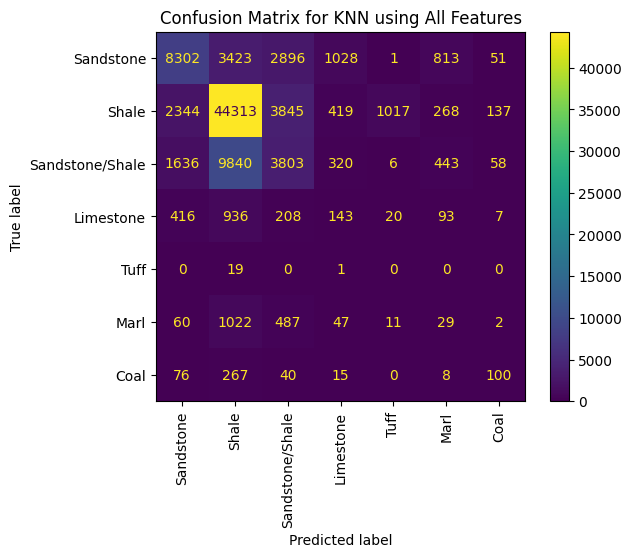

In [60]:
# Function to train and evaluate KNN using all features
def train_knn_with_all_features(X_train, y_train, X_test, y_test, n_neighbors=5):
    # Train KNN classifier
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Evaluate model performance
    print("Classification Report for KNN using All Features:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred, labels=y_train.unique())
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=y_train.unique())
    disp.plot(cmap="viridis", xticks_rotation='vertical')
    plt.title("Confusion Matrix for KNN using All Features")
    plt.show()

# Train and evaluate KNN using all features
train_knn_with_all_features(X_train_scaled, y_train, X_test_scaled, y_test, n_neighbors=5)

**The KNN classifier performed best with Shale, achieving an f1-score of 0.74 with a recall of 0.78 and precision of 0.70. Sandstone followed with an f1-score of 0.34, though its recall (0.30) suggests significant misclassification. Sandstone/Shale had a slightly lower f1-score of 0.29, primarily due to its low recall (0.24). Coal, Limestone, and Marl performed poorly, all with f1-scores at or below 0.05, indicating that the model struggled to differentiate these classes. Tuff had a recall of 0.20 but a near-zero precision, leading to an f1-score of just 0.03, likely due to its extremely low support (20 samples). I did experiment with number of neighbors parameters, trying values up to 30, but none significantly improved performance, so I stuck with 5.**

**Overall, KNN had a lower accuracy (0.56) compared to gradient boosting (0.65), and its macro and weighted averages were also lower at 0.21 and 0.55, respectively, versus 0.27 and 0.61 for gradient boosting. Gradient boosting consistently outperformed KNN across nearly all lithologies, particularly with Shale (0.80 vs. 0.74 f1-score) and Sandstone (0.55 vs. 0.34). The main advantage of KNN was its slightly higher recall for Tuff (0.20 vs. 0.00), though this is likely not meaningful given the low support. As with gradient boosting, KNN was heavily influenced by class imbalances, struggling with underrepresented lithologies like Coal and Marl.**

### Support Vector Machine (SVM)

Classification Report:
                 precision    recall  f1-score   support

           Coal       0.20      0.42      0.27       506
      Limestone       0.10      0.20      0.13      1823
           Marl       0.08      0.20      0.11      1658
      Sandstone       0.76      0.67      0.71     16514
Sandstone/Shale       0.41      0.03      0.06     16106
          Shale       0.74      0.86      0.79     52343
           Tuff       0.01      0.95      0.01        20

       accuracy                           0.65     88970
      macro avg       0.33      0.48      0.30     88970
   weighted avg       0.65      0.65      0.62     88970



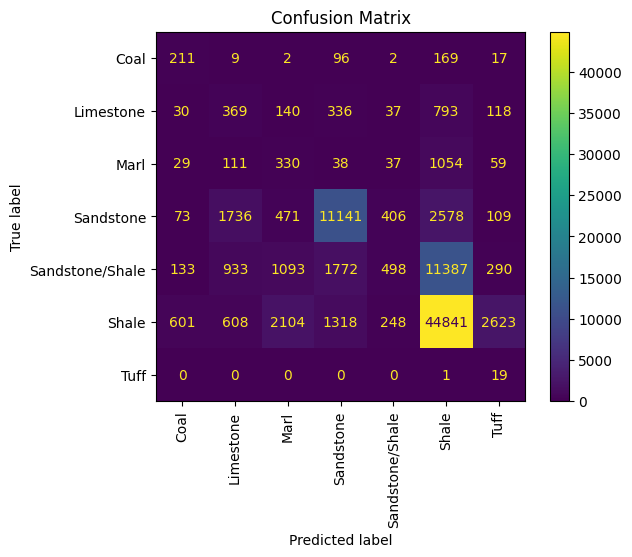

Number of support vectors per class: 6


In [61]:
# Step 1: Use LinearSVC (Much Faster Than Kernel SVM for Large Data)
svm = LinearSVC(dual=False, max_iter=5000, random_state=42, class_weight='balanced')
svm.fit(X_train_scaled, y_train)  # Train the SVM model (data is already scaled)

# Step 2: Make Predictions
y_pred = svm.predict(X_test_scaled)

# Step 3: Evaluate the Model
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# Step 4: Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=sorted(y_test.unique()))
disp.plot(cmap="viridis", xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

# Step 5: Display Support Vector Count
print(f"Number of support vectors per class: {svm.n_features_in_}")

**The SVM classifier performed best with Shale, achieving an f1-score of 0.79 due to its high recall (0.86) and precision (0.74). Sandstone followed with an f1-score of 0.71, benefiting from strong precision (0.76) and recall (0.66). Coal, Limestone, and Marl showed slight improvements over previous models, with f1-scores of 0.27, 0.13, and 0.11, respectively, largely due to higher recall. However, Sandstone/Shale performed poorly, with an f1-score of just 0.06 due to its extremely low recall (0.03). Tuff had a nearly perfect recall (0.95) but an f1-score of only 0.01, indicating severe misclassification despite correctly identifying almost all instances of Tuff somewhere in the dataset. The overall accuracy was 0.64, similar to gradient boosting but notably higher than KNN. The macro average f1-score was 0.30, slightly better than both models, while the weighted average was 0.61, in line with gradient boosting.**

**Compared to KNN and gradient boosting, SVM showed a mix of strengths and weaknesses. It outperformed both in classifying Sandstone, with a significantly higher f1-score (0.71 vs. 0.55 for gradient boosting and 0.34 for KNN). It also had a much better recall for Coal (0.42 vs. 0.19 for gradient boosting and 0.03 for KNN) and slightly better performance on Limestone and Marl. However, it struggled with Sandstone/Shale, performing far worse than both other models due to its extremely low recall. Gradient boosting had a more balanced performance across all lithologies, while KNN lagged behind in nearly all cases. One unique aspect of SVM was its perfect recall for Tuff, though its precision was so low that the actual classification value was negligible. While SVM shared a similar accuracy with gradient boosting, its performance was more polarized, excelling with certain lithologies while failing with others.**

### Assignment Questions

*Which method did you like the most?*

**I liked Gradient Boosting the most because it had the most balanced performance across all lithologies, especially for those with fewer data points, and it performed the best overall based on the metrics. The feature importance plot was also really useful for tying predictions back to the underlying physics of the logs, giving more interpretability than the other models. While all the models ran quickly, I was also able to run Gradient Boosting on the GPU, which was cool and made the process even more efficient.**


*Which method did you like the least?*

**All of the methods were relatively straightforward to implement for this dataset and had quick runtimes. With that in mind, KNN was my least favorite because it had the worst overall performance, particularly struggling with minority lithologies, and slightly slower runtimes compared to the other models. Even after experimenting with different n_neighbors values, the results didn’t improve significantly, making it feel less flexible or tunable for this problem. While it was easy to implement, its lower accuracy and limited adaptability made it the least effective choice for this dataset.**


*How did you score these supervised models?*

**I chose to score these models using classification reports and confusion matrices because they provide a clear and detailed breakdown of performance. These metrics are intuitive and make it easy to see how well the model handles the various lithologies, both numerically through precision, recall, and f1-scores, and visually in the confusion matrix plot. The classification report helps quantify where the model excels and struggles, while the confusion matrix highlights specific misclassifications, showing which lithologies are commonly confused with one another. This combination gives a well-rounded evaluation, making it easier to compare models and understand their strengths and weaknesses.**

*Did the output align with your geologic understanding?*

**Yes, the output generally aligned with my geologic understanding. Across all models, sandstone and shale consistently had better performance, which is expected for two main reasons. First, they had significantly more data available for training, giving the models more examples to learn from. Second, from a geological perspective, sandstone and shale tend to have distinct log responses across the features I used, such as GR, RHOB, and NPHI, making them easier to differentiate.**

**In contrast, other lithologies showed lower classification performance, which also makes sense. Many of these rock types, like marl and limestone, have more overlapping log characteristics, leading to increased ambiguity and misclassification. Additionally, some lithologies, like coal and tuff, had very limited representation in the dataset, which naturally made it harder for the models to classify them accurately. Overall, the models performed in a way that aligns with both the data distribution and the expected geological differences between rock types.**


*Did you hyperparameter tune? Why or why not?*

**I did not perform hyperparameter tuning for KNN, SVM, and Gradient Boosting, as the goal was to evaluate their baseline performance using default settings and compare their out-of-the-box effectiveness. This approach allowed for a fair initial comparison without introducing additional complexity. Future work could include hyperparameter optimization to further improve model performance, refine classification boundaries, and potentially enhance the accuracy of underrepresented lithologies. Techniques such as grid search, random search, or Bayesian optimization could be explored to fine-tune parameters like n_neighbors for KNN, kernel type for SVM, and learning rate or tree depth for Gradient Boosting.**


*How did you split your data? and why does that make sense for this dataset?*

**I chose to split my data on a well basis to reflect a realistic scenario where an interpreter marks lithologies in a few wells and applies the model elsewhere in the basin. This method, using two wells for training and one for testing, results in a 68/32% split, consistent with recommended practices for supervised methods. Additionally, I analyzed the lithology distribution in the data, as less common lithologies like marl and tuff may not perform as well as shale, which has the most training data.**


*What did you want to learn more about?*

**I want to explore Gradient Boosting further, as I think it offers the most potential for improving classification performance. Its ability to balance precision and recall across lithologies makes it a strong candidate for refinement. If I were able to weight certain logs more heavily based on their geologic significance or remove less informative ones, I believe I could greatly increase its accuracy across lithologies. Additionally, I’d like to experiment with hyperparameter tuning, such as adjusting the learning rate, tree depth, or number of estimators, to optimize its performance. Another area of interest is feature selection—using techniques like SHAP values or recursive feature elimination to determine which logs contribute the most to model accuracy. By fine-tuning both the model parameters and input features, I think Gradient Boosting could provide even better results and a more geologically meaningful classification.**


*Did you pre-process your data?*

**My data importation is straightforward—I assign each well a reference number and extract relevant columns from each .las file, appending them to a single dataframe. To speed up the process, I skip wells missing necessary logs or causing errors. After merging the data, I remove rows with NaN values and unrealistic entries, like negative densities. Lithology labels are numerical, so I use a dictionary to convert them to text for easier interpretation. I also remove underrepresented lithologies (Chalk, Dolomite, Halite) and reset indices for convenience. This results in a clean dataset with 279,599 rows and 11 columns, sufficient for analysis, though not "big data" by modern standards.**

*Do all models require pre-processing?*

**Yes, most models require preprocessing to ensure the data is clean, consistent, and formatted correctly for analysis. The extent of preprocessing depends on the model and dataset, but common steps include handling missing values, encoding categorical variables, and scaling features. Some models, like KNN and SVM, are particularly sensitive to feature scaling, while others, like tree-based models, handle raw data more effectively. Additionally, feature selection and engineering can further improve model performance by removing irrelevant data or creating more meaningful inputs.**

